# Portfolio Evaluation
Compares the SWDA+XMME blended portfolio against its benchmarks (full VWCE portfolio).

**Metrics computed**: 
- CAGR,
- annualized volatility,
- Sharpe ratio (using €STR risk-free rate from FRED),
- historical VaR 5%/1%,
- historical CVaR 5%/1%,
- max drawdown,
- tracking difference,
- tracking error.

In [146]:
# Imports
import os
import json
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import gspread
from oauth2client.service_account import ServiceAccountCredentials
from datetime import datetime

In [147]:
# Configuration parameters
TICKERS = {
    'SWDA':    'SWDA.MI',
    'XMME':    'XMME.MI',
    'VWCE':    'VWCE.MI',
}

SPREADSHEET_NAME = 'SWDA-XMME_periodic_rebalancing'
LOG_TAB_NAME     = 'weights_log'

# If True, months before the first log entry use the first recorded weights.
# If False, analysis starts only from the first log entry.
BACKFILL_WITH_FIRST_WEIGHTS = True

In [148]:
# Load weights log: try Google Sheets, fall back to local optimisation if authentication fails
import sys
from pathlib import Path

REPO_ROOT = Path.cwd() if (Path.cwd() / 'portfolio_allocations').exists() else Path.cwd().parent
ALLOC_DIR = REPO_ROOT / 'portfolio_allocations'
sys.path.insert(0, str(REPO_ROOT / 'src'))


def load_weights_from_sheet():
    from auth.google_credentials import load_google_credentials_dict
    scope = ['https://spreadsheets.google.com/feeds', 'https://www.googleapis.com/auth/drive']
    credentials = ServiceAccountCredentials.from_json_keyfile_dict(load_google_credentials_dict(), scope)
    client = gspread.authorize(credentials)
    sheet = client.open(SPREADSHEET_NAME).worksheet(LOG_TAB_NAME)
    # UNFORMATTED_VALUE returns the raw numeric cell values (0.86324) instead of the
    # locale-formatted strings ('0,86324') that get mis-parsed as integers (86324).
    df = pd.DataFrame(sheet.get_all_records(value_render_option='UNFORMATTED_VALUE'))
    df['Date'] = pd.to_datetime(df['Date'])
    return df.set_index('Date').sort_index()


def compute_weights_from_local_files():
    """Run the same optimisation as src/vwce/compute_portfolio_allocation.py against
    the cached allocation files in portfolio_allocations/."""
    from optimization import optimization_utils

    swda = pd.read_csv(ALLOC_DIR / 'SWDA_allocation.csv').rename(columns={'Weight (%)': 'Weight'})
    swda_geo = swda.groupby('Location')['Weight'].sum().rename(index={'--': 'Other'})

    xmme_path = ALLOC_DIR / 'XMME_allocation.xlsx'
    df_temp = pd.read_excel(xmme_path, header=None)
    header_row = df_temp.index[df_temp.eq('Name').any(axis=1)].tolist()[0]
    xmme = pd.read_excel(xmme_path, skiprows=header_row, index_col=0)
    xmme['Weighting'] = xmme['Weighting'].astype(float) * 100
    xmme = xmme.rename(columns={'Weighting': 'Weight (%)'})
    xmme_geo = xmme.groupby('Country')['Weight (%)'].sum().rename(index={'-': 'Other'})

    vwce = pd.read_excel(ALLOC_DIR / 'VWCE_market_allocation.xlsx', header=0)
    vwce_geo = vwce.rename(columns={'fundMktPercent': 'Weight'}).set_index('countryName')['Weight']
    vwce_geo.index.name = 'Country'

    vwce_geo = vwce_geo.rename(index={'United States of America': 'United States', 'South korea': 'Korea', 'Russian Federation': 'Russia'})
    xmme_geo = xmme_geo.rename(index={'Korea, Republic of': 'Korea', 'South korea': 'Korea', 'Russian Federation': 'Russia'})
    swda_geo = swda_geo.rename(index={'South Korea': 'Korea', 'Russian Federation': 'Russia'})

    df_etf = pd.DataFrame({'SWDA': swda_geo, 'XMME': xmme_geo, 'VWCE': vwce_geo}).fillna(0)
    weights = optimization_utils.compute_optimal_weights(df_etf[['SWDA', 'XMME']], df_etf['VWCE'])

    today = pd.Timestamp.today().normalize()
    return pd.DataFrame(
        {'SWDA': [float(weights[0])], 'XMME': [float(weights[1])]},
        index=pd.DatetimeIndex([today], name='Date'),
    )


try:
    weights_log = load_weights_from_sheet()
    print('Loaded weights log from Google Sheets.')
except Exception as e:
    print(f'Google Sheets unavailable ({type(e).__name__}: {e}).')
    print('Computing weights locally from cached allocation files instead.')
    weights_log = compute_weights_from_local_files()

print(weights_log)

Loaded weights log from Google Sheets.
                        SWDA     XMME
Date                                 
2026-04-21 19:14:02  0.86437  0.13563


In [149]:
# Download monthly price data from yahoo finance

all_tickers = list(TICKERS.values())
raw = yf.download(all_tickers, period='max', interval='1mo', auto_adjust=True, progress=False)
prices = raw['Close'].copy()
if isinstance(prices.columns, pd.MultiIndex):
    prices.columns = prices.columns.get_level_values(0)
ticker_to_name = {v: k for k, v in TICKERS.items()}
prices = prices.rename(columns=ticker_to_name)
if prices.index.tz is not None:
    prices.index = prices.index.tz_convert(None)
prices.index = prices.index.to_period('M').to_timestamp('M')
prices = prices.dropna(how='all')
print(f'Price data: {prices.index[0].date()} → {prices.index[-1].date()}, {len(prices)} months')
prices.tail()

Price data: 2009-09-30 → 2026-04-30, 200 months


Ticker,SWDA,VWCE,XMME
Date,,,
2025-12-31,111.809998,145.449997,64.192001
2026-01-31,112.190002,147.139999,69.195999
2026-02-28,113.580002,149.860001,73.244003
2026-03-31,108.120003,141.809998,66.208000
2026-04-30,116.559998,153.410004,74.760002


In [150]:
# Download risk-free rate from FRED (€STR, daily annualised %, resampled to monthly mean), for later computing sharpe index
rf_daily = pd.read_csv(
    'https://fred.stlouisfed.org/graph/fredgraph.csv?id=ECBESTRVOLWGTTRMDMNRT',
    parse_dates=['observation_date'],
    index_col='observation_date',
    na_values='.',
).dropna()
rf_raw = rf_daily.resample('ME').mean()
rf_raw.columns = ['rf_annual_pct']
# Convert annualised % to monthly decimal rate
rf_monthly = ((1 + rf_raw['rf_annual_pct'] / 100) ** (1 / 12) - 1).rename('rf_monthly')
print(f'Risk-free rate data: {rf_monthly.index[0].date()} → {rf_monthly.index[-1].date()}')
rf_monthly.tail()

Risk-free rate data: 2019-10-31 → 2026-04-30


observation_date
2025-12-31    0.001594
2026-01-31    0.001596
2026-02-28    0.001595
2026-03-31    0.001596
2026-04-30    0.001595
Freq: ME, Name: rf_monthly, dtype: float64

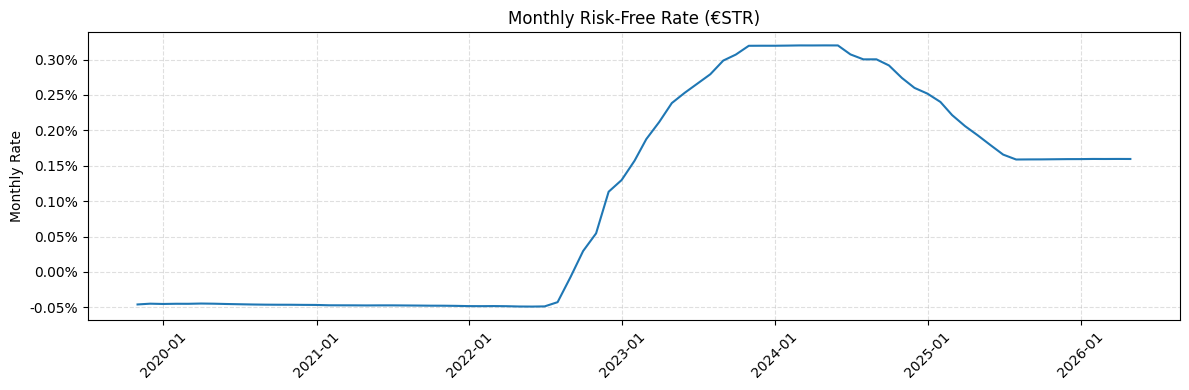

In [151]:
# Plot of the monthly risk free rate; it looks like a smoothing of the daily risk free rate
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(rf_monthly.index, rf_monthly.values, linewidth=1.5, color='#1f77b4')
ax.set_title('Monthly Risk-Free Rate (€STR)')
ax.set_ylabel('Monthly Rate')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2%}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [152]:
# Build portfolio returns from time-varying weights, then align with VWCE
# Since we only have the weights starting from April 2026, we use the first recorded weights for the previous months 

etf_returns = prices[['SWDA', 'XMME']].pct_change()

# Resample the weights log to month-end and forward-fill across months.
# Weights recorded at month-end t apply to the return earned in month t+1, so we shift by 1.
weights_me = weights_log[['SWDA', 'XMME']].resample('ME').last().ffill()
weights_aligned = weights_me.reindex(etf_returns.index, method='ffill')
if BACKFILL_WITH_FIRST_WEIGHTS:
    weights_aligned = weights_aligned.fillna(weights_me.iloc[0])

portfolio_returns = (weights_aligned.shift(1) * etf_returns).sum(axis=1, min_count=1).rename('Portfolio')

bench_returns = prices[['VWCE']].pct_change()
all_returns = pd.concat([portfolio_returns, bench_returns], axis=1).dropna()
all_returns.columns = ['Portfolio (SWDA+XMME)', 'VWCE']

# Align risk-free rate to the same span
rf_aligned = rf_monthly.reindex(all_returns.index).ffill()

print(f'Common span: {all_returns.index[0].date()} → {all_returns.index[-1].date()}, {len(all_returns)} months')

cumulative = (1 + all_returns).cumprod()
cumulative = cumulative / cumulative.iloc[0]
cumulative.tail()

Common span: 2020-02-29 → 2026-04-30, 75 months


,Portfolio (SWDA+XMME),VWCE
Date,,
2025-12-31,2.073991,2.070757
2026-01-31,2.102012,2.094818
2026-02-28,2.141201,2.133542
2026-03-31,2.024333,2.018935
2026-04-30,2.196387,2.184083


In [ ]:
# Align benchmarks and compute cumulative returns 
bench_returns = prices[['VWCE']].pct_change().reindex(portfolio_returns.index).dropna()
port_aligned = portfolio_returns.reindex(bench_returns.index)

all_returns = pd.concat([port_aligned, bench_returns], axis=1).dropna()
all_returns.columns = ['Portfolio (SWDA+XMME)', 'VWCE']

cumulative = (1 + all_returns).cumprod()
cumulative = cumulative / cumulative.iloc[0]  # rebase to 1

cumulative.tail()

,Portfolio (SWDA+XMME),VWCE
Date,,
2025-12-31,2.073991,2.070757
2026-01-31,2.102012,2.094818
2026-02-28,2.141201,2.133542
2026-03-31,2.024333,2.018935
2026-04-30,2.196387,2.184083


In [ ]:
# Risk and performance metrics

#first risk metric: maximum drawdown
def max_drawdown(cum_series):
    return ((cum_series - cum_series.cummax()) / cum_series.cummax()).min()

# second risk metric: historical VaR computed on common timespan returns
def historical_var(returns, level):
    return np.percentile(returns, level * 100)

# second risk metric: historical CVaR computed on common timespan returns
def historical_cvar(returns, level):
    var = historical_var(returns, level)
    return returns[returns <= var].mean()

n_months = len(all_returns)
n_years  = n_months / 12
mean_rf_annual = ((1 + rf_aligned) ** 12 - 1).mean()

metrics = {}
for col in all_returns.columns:
    r   = all_returns[col].values
    cum = cumulative[col]
    total_return = cum.iloc[-1] - 1
    cagr = (1 + total_return) ** (1 / n_years) - 1
    vol  = r.std() * np.sqrt(12)
    excess_monthly = all_returns[col] - rf_aligned
    sharpe = (excess_monthly.mean() * 12) / vol if vol > 0 else np.nan
    mdd  = max_drawdown(cum)
    metrics[col] = {
        'Total Return':      f'{total_return:.1%}',
        'CAGR':              f'{cagr:.2%}',
        'Ann. Std Dev':      f'{vol:.2%}',
        'Sharpe (€STR rf)':  f'{sharpe:.2f}',
        'Max Drawdown':      f'{mdd:.1%}',
        'VaR 5%  (monthly)': f'{historical_var(r, 0.05):.2%}',
        'VaR 1%  (monthly)': f'{historical_var(r, 0.01):.2%}',
        'CVaR 5% (monthly)': f'{historical_cvar(r, 0.05):.2%}',
        'CVaR 1% (monthly)': f'{historical_cvar(r, 0.01):.2%}',
    }

pd.DataFrame(metrics).T

,Total Return,CAGR,Ann. Std Dev,Sharpe (€STR rf),Max Drawdown,VaR 5% (monthly),VaR 1% (monthly),CVaR 5% (monthly),CVaR 1% (monthly)
Portfolio (SWDA+XMME),119.6%,13.42%,13.95%,0.78,-14.1%,-5.97%,-9.05%,-8.13%,-11.00%
VWCE,118.4%,13.31%,13.92%,0.77,-13.8%,-5.91%,-9.23%,-8.18%,-11.10%


In [ ]:
# Tracking difference metrics (Portfolio against its benchmark)
tracking_metrics = {}
bm = 'VWCE'

active = all_returns['Portfolio (SWDA+XMME)'] - all_returns[bm]
td = cumulative['Portfolio (SWDA+XMME)'].iloc[-1] - cumulative[bm].iloc[-1]   # cumulative gap
te = active.std() * np.sqrt(12)                                               # annualised tracking error

tracking_metrics[f'Portfolio vs {bm}'] = {
    'Tracking Difference (total)': f'{td:.2%}',
    'Tracking Error (ann.)':       f'{te:.2%}',
}

pd.DataFrame(tracking_metrics).T

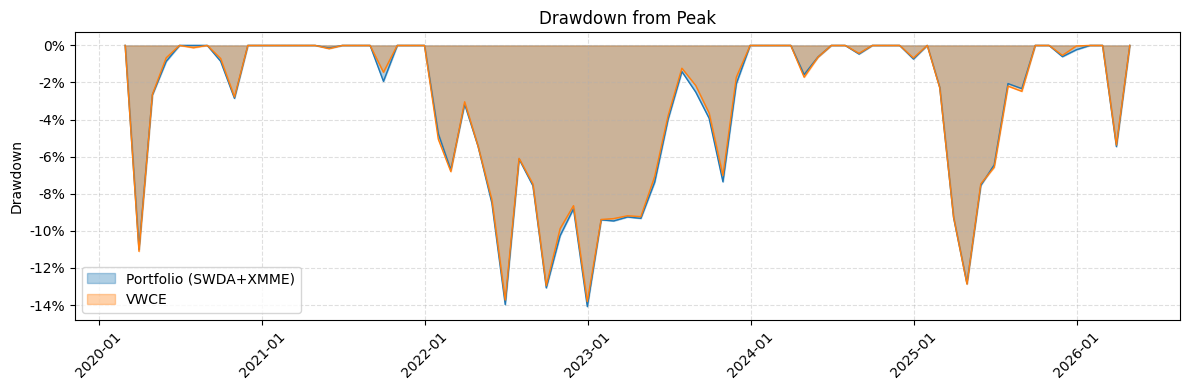

In [ ]:
# Drawdown plot
drawdowns = cumulative.apply(lambda s: (s - s.cummax()) / s.cummax())
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

fig, ax = plt.subplots(figsize=(12, 4))
for col, color in zip(drawdowns.columns, colors):
    ax.fill_between(drawdowns.index, drawdowns[col], 0, alpha=0.35, color=color, label=col)
    ax.plot(drawdowns.index, drawdowns[col], color=color, linewidth=1)

ax.set_title('Drawdown from Peak')
ax.set_ylabel('Drawdown')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
# Risk and performance metrics

#first risk metric: maximum drawdown
def max_drawdown(cum_series):
    return ((cum_series - cum_series.cummax()) / cum_series.cummax()).min()

# second risk metric: historical VaR computed on common timespan returns
def historical_var(returns, level):
    return np.percentile(returns, level * 100)

# second risk metric: historical CVaR computed on common timespan returns
def historical_cvar(returns, level):
    var = historical_var(returns, level)
    return returns[returns <= var].mean()

n_months = len(all_returns)
n_years  = n_months / 12

metrics = {}
for col in all_returns.columns:
    r   = all_returns[col].values
    cum = cumulative[col]
    total_return = cum.iloc[-1] - 1
    cagr = (1 + total_return) ** (1 / n_years) - 1
    vol  = r.std() * np.sqrt(12)
    excess_monthly = all_returns[col] - rf_aligned
    sharpe = (excess_monthly.mean() * 12) / vol if vol > 0 else np.nan
    mdd  = max_drawdown(cum)
    metrics[col] = {
        'Total Return':      f'{total_return:.1%}',
        'CAGR':              f'{cagr:.2%}',
        'Ann. Std Dev':      f'{vol:.2%}',
        'Sharpe (€STR rf)':  f'{sharpe:.2f}',
        'Max Drawdown':      f'{mdd:.1%}',
        'VaR 5%  (monthly)': f'{historical_var(r, 0.05):.2%}',
        'VaR 1%  (monthly)': f'{historical_var(r, 0.01):.2%}',
        'CVaR 5% (monthly)': f'{historical_cvar(r, 0.05):.2%}',
        'CVaR 1% (monthly)': f'{historical_cvar(r, 0.01):.2%}',
    }

pd.DataFrame(metrics).T

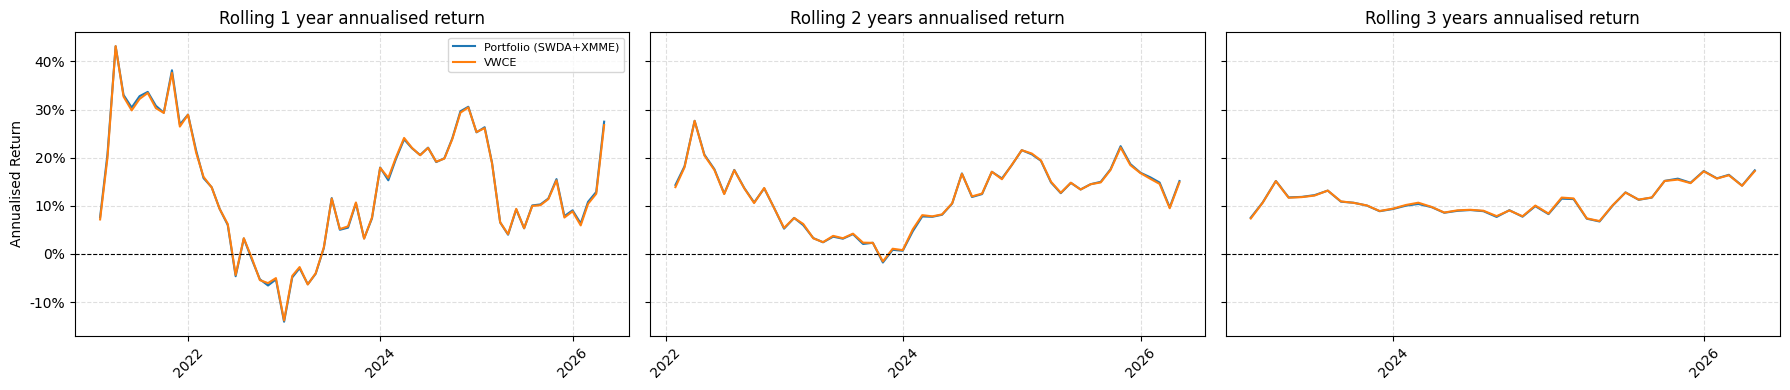

In [ ]:
# Rolling annualised returns over 1y / 2y / 3y windows
windows = {'1 year': 12, '2 years': 24, '3 years': 36}
series_colors = {'Portfolio (SWDA+XMME)': '#1f77b4', 'VWCE': '#ff7f0e'}

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for ax, (label, w) in zip(axes, windows.items()):
    for col in all_returns.columns:
        rolling_cum = (1 + all_returns[col]).rolling(w).apply(np.prod, raw=True)
        rolling_ann = rolling_cum ** (12 / w) - 1
        ax.plot(rolling_ann.index, rolling_ann, label=col, color=series_colors[col], linewidth=1.5)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'Rolling {label} annualised return')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.tick_params(axis='x', rotation=45)

axes[0].set_ylabel('Annualised Return')
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# Same risk/performance metrics but computed on rolling 1y / 2y / 3y windows.
# Each metric becomes a time series across rolling windows; we summarise with
# the mean across windows (and also the worst realisation for drawdown and
# tracking difference).
from IPython.display import display

rolling_windows = {'1y': 12, '2y': 24, '3y': 36}

def window_mdd(r):
    cum = (1 + pd.Series(r)).cumprod()
    return ((cum - cum.cummax()) / cum.cummax()).min()

def window_cvar(r, level):
    q = np.quantile(r, level)
    tail = r[r <= q]
    return tail.mean() if len(tail) else np.nan

perf_rows = {}
track_rows = {}

for label, w in rolling_windows.items():
    for col in all_returns.columns:
        r = all_returns[col]
        cum    = (1 + r).rolling(w).apply(np.prod, raw=True)
        cagr   = cum ** (12 / w) - 1
        vol    = r.rolling(w).std() * np.sqrt(12)
        sharpe = ((r - rf_aligned).rolling(w).mean() * 12) / vol
        mdd    = r.rolling(w).apply(window_mdd, raw=True)
        var5   = r.rolling(w).quantile(0.05)
        var1   = r.rolling(w).quantile(0.01)
        cvar5  = r.rolling(w).apply(lambda x: window_cvar(x, 0.05), raw=True)
        cvar1  = r.rolling(w).apply(lambda x: window_cvar(x, 0.01), raw=True)

        perf_rows[(label, col)] = {
            'CAGR (mean)':             f'{cagr.mean():.2%}',
            'Ann. Std Dev (mean)':     f'{vol.mean():.2%}',
            'Sharpe (mean, €STR rf)':  f'{sharpe.mean():.2f}',
            'Max Drawdown (mean)':     f'{mdd.mean():.1%}',
            'Max Drawdown (worst)':    f'{mdd.min():.1%}',
            'VaR 5%  (monthly, mean)': f'{var5.mean():.2%}',
            'VaR 1%  (monthly, mean)': f'{var1.mean():.2%}',
            'CVaR 5% (monthly, mean)': f'{cvar5.mean():.2%}',
            'CVaR 1% (monthly, mean)': f'{cvar1.mean():.2%}',
        }

    active = all_returns['Portfolio (SWDA+XMME)'] - all_returns['VWCE']
    td = (1 + active).rolling(w).apply(np.prod, raw=True) - 1
    te = active.rolling(w).std() * np.sqrt(12)
    track_rows[(label, 'Portfolio vs VWCE')] = {
        'Tracking Difference (window, mean)':  f'{td.mean():.2%}',
        'Tracking Difference (window, worst)': f'{td.min():.2%}',
        'Tracking Error (ann., mean)':         f'{te.mean():.2%}',
    }

rolling_perf_table = pd.DataFrame(perf_rows).T
rolling_perf_table.index = pd.MultiIndex.from_tuples(rolling_perf_table.index, names=['Window', 'Series'])

rolling_track_table = pd.DataFrame(track_rows).T
rolling_track_table.index = pd.MultiIndex.from_tuples(rolling_track_table.index, names=['Window', 'Series'])

print('Rolling risk & performance metrics:')
display(rolling_perf_table)
print('\nRolling tracking metrics:')
display(rolling_track_table)